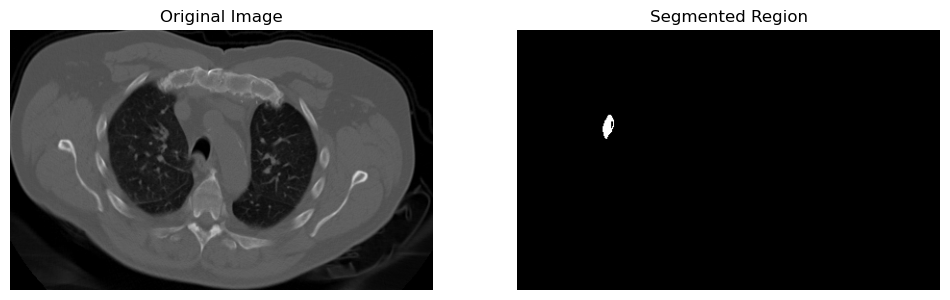

Region growing segmentation completed. Check the output image.


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def region_growing(image, seed_point, threshold):
    # Create an empty mask to keep track of the segmented region
    mask = np.zeros_like(image, dtype=np.uint8)

    # Initialize the list of pixels to process
    to_process = [seed_point]
    region_mean = image[seed_point]

    while to_process:
        # Pop the last pixel from the list
        current_pixel = to_process.pop()

        # If the pixel is already in the mask, skip it
        if mask[current_pixel]:
            continue

        # Add the pixel to the mask
        mask[current_pixel] = 255
        
        # Check neighboring pixels
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:  # 4-connectivity
            neighbor = (current_pixel[0] + dx, current_pixel[1] + dy)
            if (0 <= neighbor[0] < image.shape[0] and
                0 <= neighbor[1] < image.shape[1] and
                not mask[neighbor] and
                abs(int(image[neighbor]) - int(region_mean)) < threshold):
                
                to_process.append(neighbor)

        # Update the region mean
        region_mean = np.mean(image[mask == 255])

    return mask

# Load the CT scan image
image_path = '000117 (4).png'  # Update with your image path
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Preprocess the image (optional)
blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

# Set seed point and threshold for region growing
seed_point = (100, 100)  # Change based on your image
threshold = 15  # Adjust based on your needs

# Perform region growing segmentation
segmented_mask = region_growing(blurred_image, seed_point, threshold)

# Display the results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Segmented Region')
plt.imshow(segmented_mask, cmap='gray')
plt.axis('off')

plt.show()

# Save the result (optional)
output_path = 'segmented_lung.png'  # Path to save the segmented image
cv2.imwrite(output_path, segmented_mask)

print("Region growing segmentation completed. Check the output image.")
